In [38]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['von_sandt_ufer'].sum())
header = 'von_sandt_ufer'

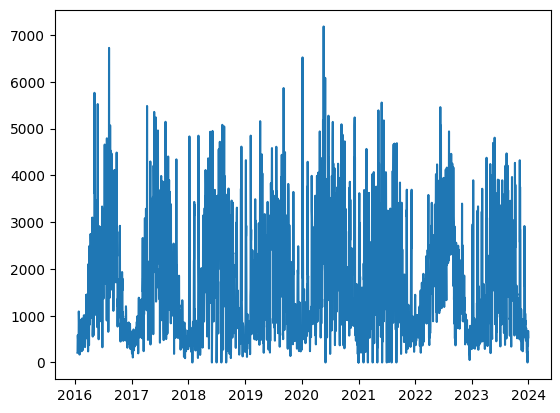

In [39]:
plt.plot(df[header])

In [40]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

In [41]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [42]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



Seasonal ARIMA

In [43]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,9236,18966,25132,47534,71389,53077,81351,92924,83694,37835,22912,18353
2017,14185,19916,46249,48622,72142,82889,77953,77374,52534,43163,25862,14045
2018,26395,28998,37480,64801,74047,70966,85442,78068,59138,49347,37313,33181
2019,32151,45347,42735,57424,59129,76578,71257,75118,56522,49436,34043,29636
2020,40846,35886,56905,69511,91679,79173,92651,77859,75868,51522,47935,45248
2021,37036,48851,50094,52654,56607,65236,51379,64127,63191,42717,32831,32775
2022,24313,26248,52349,51445,76768,81212,85369,97972,56678,53381,33574,15076
2023,29487,34018,41206,51623,71900,72199,61004,73251,62480,45131,34277,23883


Monatlich


In [44]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1     26706.125
2     32278.750
3     44018.750
4     55451.750
5     71707.625
6     72666.250
7     75800.750
8     79586.625
9     63763.125
10    46566.500
11    33593.375
12    26524.625
Name: von_sandt_ufer, dtype: float64


In [45]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [46]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [47]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,von_sandt_ufer
year-month,,
2016-01-01,2016-01-01,9236
2016-02-01,2016-02-01,18966
2016-03-01,2016-03-01,25132
2016-04-01,2016-04-01,47534
2016-05-01,2016-05-01,71389
...,...,...
2023-08-01,2023-08-01,73251
2023-09-01,2023-09-01,62480
2023-10-01,2023-10-01,45131


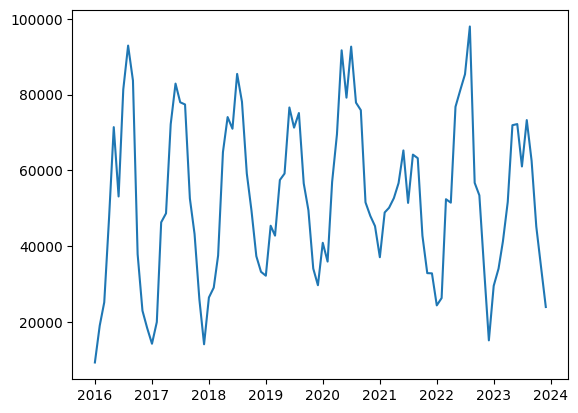

In [48]:
plt.plot(df_month[header])

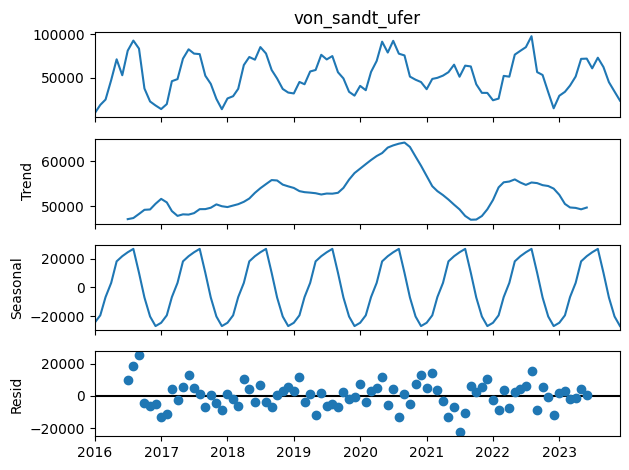

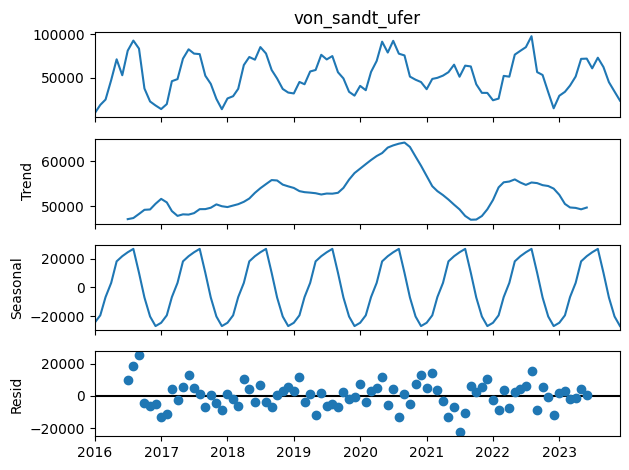

In [49]:
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [50]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -4.8849
p-value = 0.0000


In [51]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,von_sandt_ufer,scaled,log
year-month,,,,
2016-01-01,2016-01-01,9236,1.000000,0.000000
2016-02-01,2016-02-01,18966,10743.627908,9.282068
2016-03-01,2016-03-01,25132,17551.340516,9.772886
2016-04-01,2016-04-01,47534,42284.778376,10.652182
2016-05-01,2016-05-01,71389,68622.433950,11.136375
...,...,...,...,...
2023-08-01,2023-08-01,73251,70678.217420,11.165893
2023-09-01,2023-09-01,62480,58786.249775,10.981663
2023-10-01,2023-10-01,45131,39631.691546,10.587384


In [52]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [53]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -5.4005
P-value = 0.0000


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_10116\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


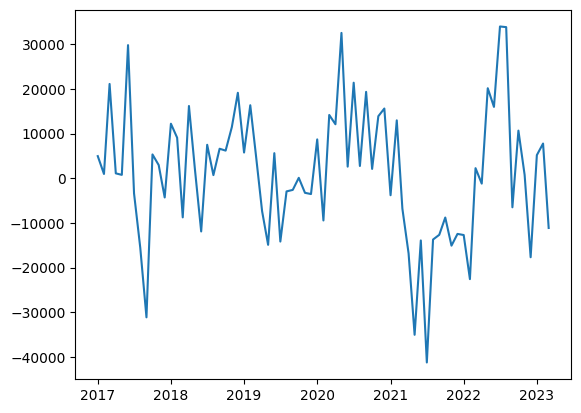

In [54]:
plt.plot(df_train['differences'])

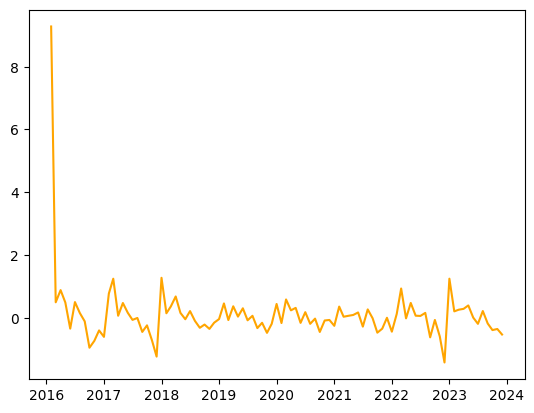

In [55]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [56]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -10.1666
P-value = 0.0000


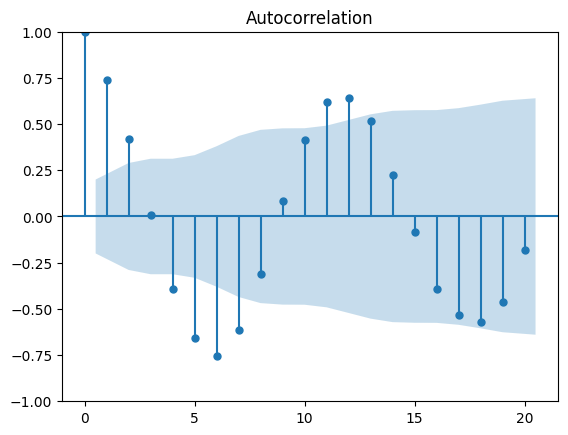

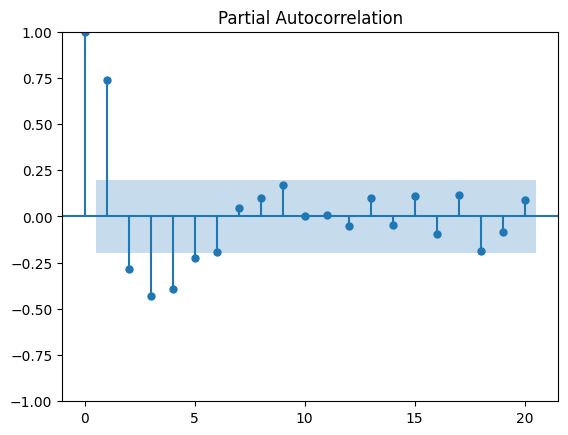

In [57]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [58]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,von_sandt_ufer,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,9236,1.000000,0.000000,NaN,1,8.640144,-8.640144
2016-02-01,2016-02-01,18966,10743.627908,9.282068,9.282068,2,10.034308,-0.752240
2016-03-01,2016-03-01,25132,17551.340516,9.772886,0.490818,3,10.510882,-0.737997
2016-04-01,2016-04-01,47534,42284.778376,10.652182,0.879297,4,10.828123,-0.175941
2016-05-01,2016-05-01,71389,68622.433950,11.136375,0.484192,5,11.128414,0.007961
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,73251,70678.217420,11.165893,0.212342,8,11.250140,-0.084247
2023-09-01,2023-09-01,62480,58786.249775,10.981663,-0.184229,9,10.990071,-0.008408
2023-10-01,2023-10-01,45131,39631.691546,10.587384,-0.394279,10,10.617612,-0.030228


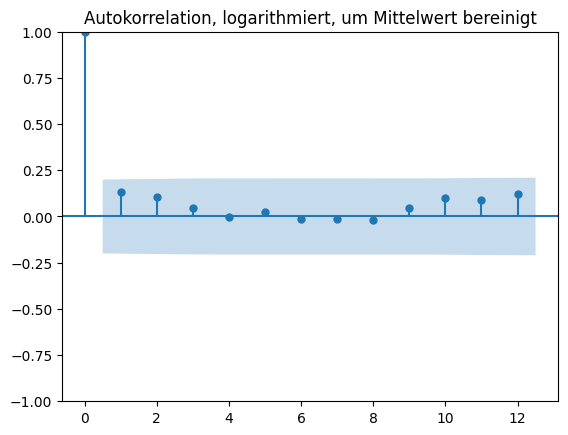

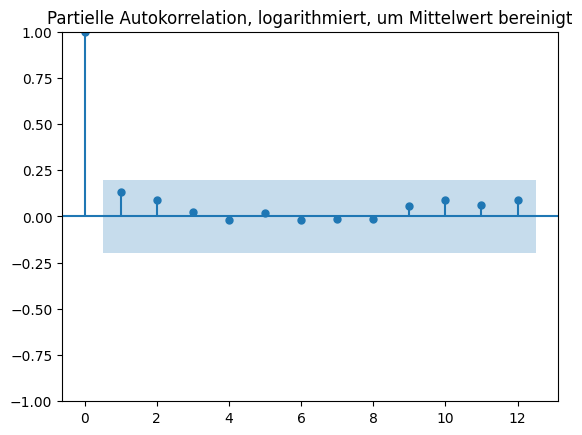

In [59]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

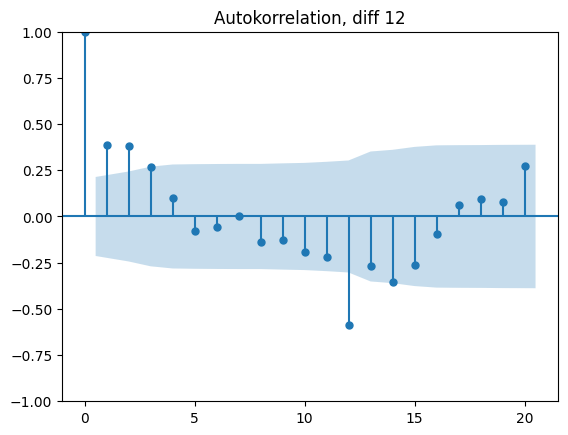

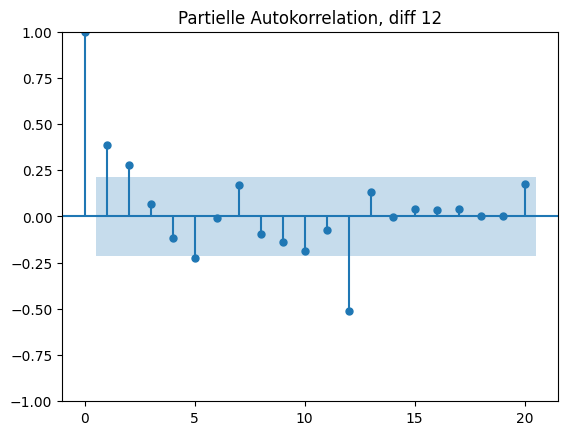

In [60]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [61]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()
result9 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(3, 1, 0, seasonal)).fit()
result10 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 3, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))
print('ARIMA (0,1,1)x(3,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result9.llf, result9.aic))
print('ARIMA (0,1,1)x(0,1,3,12) LL {:.4f}, AIC: {:.4f}'.format(result10.llf, result10.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -112.7813, AIC: 227.5626
ARIMA (0,1,0)x(0,1,0,12) LL -114.3919, AIC: 230.7838
ARIMA (1,0,0)x(0,1,1,12) LL -111.9449, AIC: 229.8898
ARIMA (1,0,0)x(0,1,2,12) LL -111.6787, AIC: 231.3574
ARIMA (1,1,0)x(0,1,2,12) LL -108.8887, AIC: 225.7773
ARIMA (0,0,1)x(0,1,2,12) LL -111.7165, AIC: 231.4330
ARIMA (0,1,1)x(0,1,2,12) LL -110.2193, AIC: 226.4386
ARIMA (0,1,1)x(2,1,0,12) LL -110.0232, AIC: 228.0464
ARIMA (0,1,1)x(3,1,0,12) LL -110.0228, AIC: 230.0457
ARIMA (0,1,1)x(0,1,3,12) LL -109.9442, AIC: 229.8883


In [62]:
print(result7.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -111.945
Date:                              Mon, 10 Feb 2025   AIC                            229.890
Time:                                      23:57:28   BIC                            236.842
Sample:                                  01-01-2016   HQIC                           232.666
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1740      0.095      1.824      0.068      -0.013       0.361
ma.S.L12       0.18

In [63]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean      unlogged   new_predict
2023-04-01       10.665227  42839.984361  48036.870832
2023-05-01       11.154596  69884.301408  72531.920566
2023-06-01       11.249881  76870.754930  78859.812899
2023-07-01       11.299847  80809.299527  82427.100089
2023-08-01       11.492440  97972.313151  97972.283633
2023-09-01       10.774900  47805.700952  52534.506126
2023-10-01       10.765345  47351.071195  52122.730947
2023-11-01       10.098989  24318.406063  31261.184436
2023-12-01        8.484792   4840.590321  13619.398013
2024-01-01        9.948872  20928.598501  28190.908908
2024-02-01       10.133318  25167.734169  32030.452677
2024-03-01       10.398660  32815.613003  38957.422660
2024-04-01       10.619018  40905.416753  46284.660573
2024-05-01       11.155487  69946.604382  72588.350700
2024-06-01       11.239116  76047.728275  78114.366866
2024-07-01       11.335495  83741.929549  85083.292815
2024-08-01       11.510375  99745.323439  99578.165382
2024-09-01

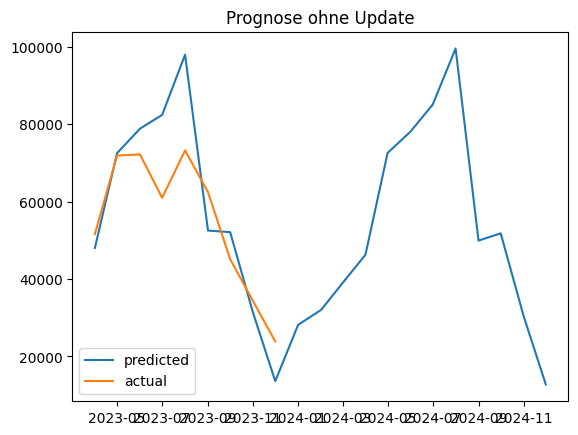

mean absolute error (mae): ARIMA: 9693.3210
mean squared error (mse): ARIMA: 154438997.2961
mean absolute percentage error (mape): ARIMA: 0.1879


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_10116\1951914538.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_10116\1951914538.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykern

In [64]:
plt.plot(y_pred_no_update['new_predict'], label='predicted')
plt.plot(df_test_seas[header], label='actual')

plt.title('Prognose ohne Update')
plt.legend()
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [68]:
arima = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2023-04-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,10.665227,42839.984361,48036.870832
2023-05-01,11.186027,72115.660879,74552.946318
2023-06-01,11.266568,78164.294209,80031.419817
2023-07-01,11.274847,78814.110156,80619.982431
2023-08-01,11.353201,85237.857586,86438.210805
2023-09-01,10.569062,38912.163331,44479.296377
2023-10-01,10.706210,44632.159214,49660.110645
2023-11-01,9.997605,21973.769822,29137.559675
2023-12-01,8.465082,4746.115929,13533.829022
2024-01-01,10.365066,31731.539397,37975.536638


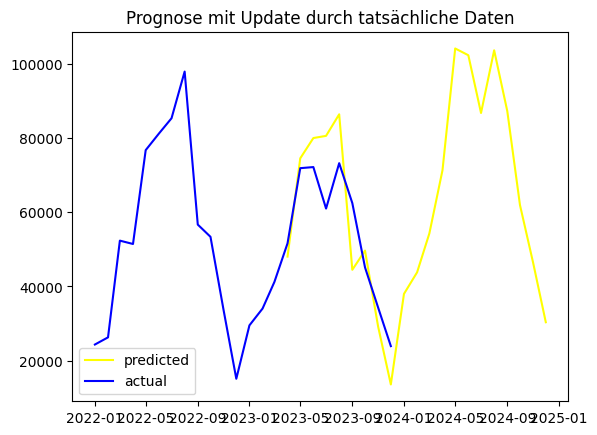

In [69]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [70]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 9432.5682
mean squared error (mse): ARIMA: 124221322.5873
mean absolute percentage error (mape): ARIMA: 0.1876
